# Proyecto final de aprendizaje automático

In [160]:
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

## Paso 1: Definición del problema

### Objetivo: 
- Predecir la demanda futura de productos farmacéuticos para optimizar la gestión de inventario.
- Evitar quiebres de stock y sobrestock. 
- Reducir pérdida por vencimientos y mejorar disponibilidad.
##### Plan B: Predecir el total que abonará el cliente en una transacción, considerando cantidad, producto, rubro, cobertura, descuentos e impuestos.

## Paso 2: Obtencion y carga del conjunto de datos

In [161]:
df = pd.read_csv('../data/raw/farmacia-datos.csv', sep=';',encoding='latin-1')
df.head(12)

,Fecha,Tipo Mov.,Fac. Tipo,Fac. Suc.,Fac. Nun.,Fisc. Numero,Tipo Pago,Cant.,Precio,Producto,Sub. Total,Rubro,Cobertura,Ajustes,Desc. Adic.,Total. Cliente,IVA,Tasa Iva,Total Gravado,Total sin Gravar
0,01/01/25 01.13.46,F,B,0,379923,NaN,E,1,9344,ACTRON PEDIATRICO 4% susp.oral x 100 ml,9344,FARMACIA,0,0,0,9344,0,0,0,9344
1,01/01/25 01.59.21,F,B,0,379924,NaN,E,1,"8174,96",AMOXIDAL 500 mg comp.rec.x 21,"8174,96",FARMACIA,"3032,85",0,0,"5142,11",0,0,0,"8174,96"
2,01/01/25 02.01.59,F,B,0,379925,NaN,E,1,"8174,96",AMOXIDAL 500 mg comp.rec.x 21,"8174,96",FARMACIA,"5318,1",0,0,"2856,86",0,0,0,"8174,96"
3,01/01/25 02.04.14,F,B,0,379926,NaN,E,1,"8086,82",MUELITA FORTE GEL gel pomo x 10 g,"8086,82",FARMACIA,0,0,0,"8086,82",0,0,0,"8086,82"
4,01/01/25 02.08.35,F,B,0,379927,NaN,E,1,"26750,12",DIOXAFLEX B12 comp.x 20,"26750,12",FARMACIA,0,0,0,"26750,12",0,0,0,"26750,12"
5,01/01/25 06.06.42,F,B,0,379928,NaN,E,1,"24480,51",EVATEST DIGITAL env.x 1,"24480,51",FARMACIA,0,0,0,"24480,51","4248,683554",21,"20231,82645",0
6,01/01/25 06.22.37,F,B,0,379929,NaN,E,1,4800,GEN LP KETOROLAC blister 20 mg x 10,4800,FARMACIA,0,0,0,4800,0,0,0,4800
7,01/01/25 06.22.37,F,B,0,379929,NaN,E,1,4961,CAFIASPIRINA PLUS comp.x 20,4961,FARMACIA,0,0,0,4961,0,0,0,4961
8,01/01/25 07.46.36,F,B,0,379930,NaN,E,2,3500,ACCESORIO (unica),7000,FARMACIA,0,0,0,7000,"1214,876033",21,"5785,123967",0
9,02/01/25 08.08.38,F,B,0,379931,NaN,E,1,3430,QURA PLUS comp.rec.x 20,3430,FARMACIA,0,0,343,3087,0,0,0,3430


> Los datos provienen de un archivo Excel extraído del sistema de facturación de una farmacia real, convertido posteriormente a formato CSV para su procesamiento.

## Paso 3: Almacenar la información

In [162]:
df.columns = df.columns.str.replace('.', '', regex=False).str.replace(' ', '_')

Para la ejecución de las consultas SQL se normalizaron los nombres de columnas para garantizar la correcta agregación de variables numéricas.

In [163]:
# Create connection to SQLite
conn = sqlite3.connect('farmacia-datos.db')

In [164]:
# Save table
df.to_sql('ventas', conn, if_exists='replace', index=False)

117415

In [165]:
# Verify that the table exists
query = 'SELECT * FROM ventas LIMIT 5;'
pd.read_sql(query, conn)

,Fecha,Tipo_Mov,Fac_Tipo,Fac_Suc,Fac_Nun,Fisc_Numero,Tipo_Pago,Cant,Precio,Producto,Sub_Total,Rubro,Cobertura,Ajustes,Desc_Adic,Total_Cliente,IVA,Tasa_Iva,Total_Gravado,Total_sin_Gravar
0,01/01/25 01.13.46,F,B,0,379923,None,E,1,9344,ACTRON PEDIATRICO 4% susp.oral x 100 ml,9344,FARMACIA,0,0,0,9344,0,0,0,9344
1,01/01/25 01.59.21,F,B,0,379924,None,E,1,"8174,96",AMOXIDAL 500 mg comp.rec.x 21,"8174,96",FARMACIA,"3032,85",0,0,"5142,11",0,0,0,"8174,96"
2,01/01/25 02.01.59,F,B,0,379925,None,E,1,"8174,96",AMOXIDAL 500 mg comp.rec.x 21,"8174,96",FARMACIA,"5318,1",0,0,"2856,86",0,0,0,"8174,96"
3,01/01/25 02.04.14,F,B,0,379926,None,E,1,"8086,82",MUELITA FORTE GEL gel pomo x 10 g,"8086,82",FARMACIA,0,0,0,"8086,82",0,0,0,"8086,82"
4,01/01/25 02.08.35,F,B,0,379927,None,E,1,"26750,12",DIOXAFLEX B12 comp.x 20,"26750,12",FARMACIA,0,0,0,"26750,12",0,0,0,"26750,12"


**Top 10 productos más vendidos**

In [166]:
# Execute a real SQL query
query_top_10 = '''
SELECT Producto, SUM("Cant") AS Demanda_total
FROM ventas
GROUP BY Producto
ORDER BY Demanda_total DESC
LIMIT 10;
'''
pd.read_sql(query_top_10, conn)

,Producto,Demanda_total
0,BUSCAPINA COMPOSITUM comp.rec.x 20,2648
1,QURA PLUS comp.rec.x 20,2602
2,GEN LP IBUPROFENO blister 600 mg x 10,2135
3,SERTAL COMPUESTO comp.rec.x 20,1786
4,GEN LP OMEPRAZOL blister 20 mg x 15,1576
5,ALIKAL (unica),1483
6,MYLANTA EXTRA comp.mast.x 24,1278
7,ASPIRINA PREVENT comp.cub.enterica x 50,1160
8,CAFIASPIRINA comp.x 30,1041
9,TAFIROL 1G X 8 (unica),983


> Se almacenaron los datos en una base de datos SQLite y se realizaron consultas SQL desde Python para identificar productos de alta rotación y patrones de demanda.

**Demanda total por producto**

In [167]:
query_product = '''
SELECT Producto, SUM("Cant") AS Demanda_total
FROM ventas
GROUP BY Producto;
'''
pd.read_sql(query_product, conn)

,Producto,Demanda_total
0,None,1
1,CHUP.MANZANITA(C/DIBUJO)T/SILIC.+3M RED - ES...,1
2,(unica),4
3,1,1
4,1 1,7
...,...,...
7671,q,1
7672,|,1
7673,º,3
7674,ÓLEO Calcáreo x 240 ml.,1


Esta consulta permite identificar los productos con mayor volumen de ventas acumuladas, fundamentales para la gestión de stock y la priorización de reposición.

**Demanda agregada por día**

In [168]:
query_per_day = """
SELECT strftime('%Y-%m', Fecha) AS mes, SUM("Cant") AS Demanda_mensual
FROM ventas
GROUP BY mes
ORDER BY mes;
"""

pd.read_sql(query_per_day, conn)

,mes,Demanda_mensual
0,None,160639


La agregación diaria por producto permite modelar la demanda como una serie temporal, base para la predicción de consumo futuro.

In [169]:
query_coverage = """
SELECT Cobertura, SUM("Cant") AS Demanda_total
FROM ventas
GROUP BY Cobertura;
"""
pd.read_sql(query_coverage, conn)


,Cobertura,Demanda_total
0,"-157953,92",1
1,0,107170
2,10000,1
3,"10000,188",1
4,"10001,04",3
...,...,...
23016,"9993,308",1
23017,"9995,3",3
23018,"9998,392",2
23019,"9998,952",1


La presencia de cobertura médica incrementa la demanda, lo cual debe considerarse en la planificación de inventario.

## Paso 4: Realiza un análisis descriptivo

Variable clave: `Cant`

In [170]:
df['Cant'].describe()

count    117415.000000
mean          1.368130
std           1.862115
min           0.000000
25%           1.000000
50%           1.000000
75%           1.000000
max         106.000000
Name: Cant, dtype: float64

In [171]:
average = df['Cant'].mean()
median = df['Cant'].median()
mode = df['Cant'].mode()[0]
variance = df['Cant'].var()
skewness = df['Cant'].skew()

In [172]:
print(f'Media:     {average:.2f}')
print(f'Mediana:   {median:.2f}')
print(f'Moda:      {mode:.2f}')
print(f'Varianza:  {variance:.2f}')
print(f'Asimetría: {skewness:.2f}')

Media:     1.37
Mediana:   1.00
Moda:      1.00
Varianza:  3.47
Asimetría: 12.14


- **Media** (1.37) vs **Mediana** (1.00): El hecho de que la media sea mayor que la mediana indica que la distribución está sesgada a la derecha. Mientras que la mayoría de los clientes compran solo 1 unidad (mediana), hay un grupo pequeño de transacciones con cantidades muy altas que elevan el promedio.
- **Moda** (1.00): Es el valor más frecuente. Esto confirma que el comportamiento estándar en la farmacia es la compra de una única unidad por producto (típico de medicamentos bajo receta).
- **Varianza** (3.47): La desviación estándar sería la raíz cuadrada de esto (≈1.86). Aunque la mayoría compra 1 unidad, hay una variabilidad considerable. En términos de negocio, esto sugiere que conviven dos tipos de clientes: el consumidor final (compra 1 unidad) y posiblemente clientes institucionales o crónicos (compran varias cajas o tratamientos completos).
- **Asimetría Positiva Extrema**: Un valor de 12.14 es extremadamente alto (en una distribución normal sería 0).   

Debido a esta asimetría, será necesario decidir si se eliminan esos valores extremos para entrenar el modelo de Machine Learning o si se tratan de forma especial, ya que podrían distorsionar las predicciones.

In [173]:
df.shape

(117415, 20)

In [174]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117415 entries, 0 to 117414
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Fecha             117415 non-null  object 
 1   Tipo_Mov          117415 non-null  object 
 2   Fac_Tipo          117415 non-null  object 
 3   Fac_Suc           117415 non-null  int64  
 4   Fac_Nun           117415 non-null  int64  
 5   Fisc_Numero       0 non-null       float64
 6   Tipo_Pago         117415 non-null  object 
 7   Cant              117415 non-null  int64  
 8   Precio            117415 non-null  object 
 9   Producto          117414 non-null  object 
 10  Sub_Total         117415 non-null  object 
 11  Rubro             117415 non-null  object 
 12  Cobertura         117415 non-null  object 
 13  Ajustes           117415 non-null  int64  
 14  Desc_Adic         117415 non-null  object 
 15  Total_Cliente     117415 non-null  object 
 16  IVA               11

In [175]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Fac_Suc,117415.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
Fac_Nun,117415.0,417643.591407,22420.160070,379923.0,398031.0,416281.0,437618.5,455865.0
Fisc_Numero,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cant,117415.0,1.368130,1.862115,0.0,1.0,1.0,1.0,106.0
Ajustes,117415.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
Tasa_Iva,117415.0,4.090363,8.316679,0.0,0.0,0.0,0.0,21.0


In [176]:
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d/%m/%y %H.%M.%S')

In [177]:
df.head(5)

,Fecha,Tipo_Mov,Fac_Tipo,Fac_Suc,Fac_Nun,Fisc_Numero,Tipo_Pago,Cant,Precio,Producto,Sub_Total,Rubro,Cobertura,Ajustes,Desc_Adic,Total_Cliente,IVA,Tasa_Iva,Total_Gravado,Total_sin_Gravar
0,2025-01-01 01:13:46,F,B,0,379923,NaN,E,1,9344,ACTRON PEDIATRICO 4% susp.oral x 100 ml,9344,FARMACIA,0,0,0,9344,0,0,0,9344
1,2025-01-01 01:59:21,F,B,0,379924,NaN,E,1,"8174,96",AMOXIDAL 500 mg comp.rec.x 21,"8174,96",FARMACIA,"3032,85",0,0,"5142,11",0,0,0,"8174,96"
2,2025-01-01 02:01:59,F,B,0,379925,NaN,E,1,"8174,96",AMOXIDAL 500 mg comp.rec.x 21,"8174,96",FARMACIA,"5318,1",0,0,"2856,86",0,0,0,"8174,96"
3,2025-01-01 02:04:14,F,B,0,379926,NaN,E,1,"8086,82",MUELITA FORTE GEL gel pomo x 10 g,"8086,82",FARMACIA,0,0,0,"8086,82",0,0,0,"8086,82"
4,2025-01-01 02:08:35,F,B,0,379927,NaN,E,1,"26750,12",DIOXAFLEX B12 comp.x 20,"26750,12",FARMACIA,0,0,0,"26750,12",0,0,0,"26750,12"


In [178]:
df.duplicated().sum()

np.int64(121)

In [179]:
duplicated = df[df.duplicated(keep=False)]
duplicated

,Fecha,Tipo_Mov,Fac_Tipo,Fac_Suc,Fac_Nun,Fisc_Numero,Tipo_Pago,Cant,Precio,Producto,Sub_Total,Rubro,Cobertura,Ajustes,Desc_Adic,Total_Cliente,IVA,Tasa_Iva,Total_Gravado,Total_sin_Gravar
2122,2025-01-07 14:56:11,F,B,0,381215,NaN,E,1,3200,IMPULSE VERY PINK BS AERO 150,3200,PERFUMERIA,0,0,0,3200,"555,3719008",21,"2644,628099",0
2123,2025-01-07 14:56:11,F,B,0,381215,NaN,E,1,3200,IMPULSE VERY PINK BS AERO 150,3200,PERFUMERIA,0,0,0,3200,"555,3719008",21,"2644,628099",0
2124,2025-01-07 14:56:11,F,B,0,381215,NaN,E,1,3200,IMPULSE VERY PINK BS AERO 150,3200,PERFUMERIA,0,0,0,3200,"555,3719008",21,"2644,628099",0
4858,2025-01-14 16:00:35,F,B,0,382867,NaN,E,1,"21971,64",MEMANTINA RICHET 10 mg comp.x 30,"21971,64",FARMACIA,"10985,82",0,0,"10985,82",0,0,0,"21971,64"
4859,2025-01-14 16:00:35,F,B,0,382867,NaN,E,1,"21971,64",MEMANTINA RICHET 10 mg comp.x 30,"21971,64",FARMACIA,"10985,82",0,0,"10985,82",0,0,0,"21971,64"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112196,2025-12-06 11:10:48,F,B,0,452638,NaN,E,1,"8157,79",TAFIROL PLUS RAPIDA ACCION cáps.bl. x 16,"8157,79",FARMACIA,0,0,0,"8157,79",0,0,0,"8157,79"
114299,2025-12-13 09:11:38,F,B,0,453912,NaN,E,1,9358,LOTRIAL 10 mg comp.x 30,9358,FARMACIA,0,0,0,9358,0,0,0,9358
114300,2025-12-13 09:11:38,F,B,0,453912,NaN,E,1,9358,LOTRIAL 10 mg comp.x 30,9358,FARMACIA,0,0,0,9358,0,0,0,9358
115321,2025-12-16 16:31:39,F,B,0,454552,NaN,E,1,"9641,696",BAGOVIT CAPILAR PLASMA VEG 350,"9641,696",PERFUMERIA,0,0,0,"9641,696","1673,352198",21,"7968,343802",0


### Limpieza de datos: Eliminar información irrelevante

In [180]:
products_no_name = df[df['Producto'].str.len() <= 4]['Producto'].unique()
products_no_name

array(['1 1', 'A1 1', '5200', 'º', '|', 'LIMA', 'q', '1'], dtype=object)

In [181]:
df = df[df['Producto'].str.len() > 4]

Se eliminaron registros cuyos nombres de producto tenían una longitud menor o igual a cuatro caracteres, ya que correspondían a valores erróneos o incompletos que no aportaban información relevante al análisis.

In [182]:
df['Fisc_Numero'].isna().sum()

np.int64(117398)

In [183]:
(df['Fac_Suc'] == 0).sum()

np.int64(117398)

In [184]:
df['Tipo_Mov'].unique()

array(['F'], dtype=object)

In [185]:
df['Fac_Tipo'].value_counts(dropna=False)

Fac_Tipo
B    117234
A       164
Name: count, dtype: int64

In [186]:
df['IVA'].value_counts(dropna=False)

IVA
0              94536
173,553719       982
520,661157       673
867,768595       658
780,9917355      641
               ...  
2965,42562         1
225,3775537        1
1662,644628        1
4947,476569        1
491,7738347        1
Name: count, Length: 4217, dtype: int64

In [187]:
df['Tasa_Iva'].value_counts(dropna=False)

Tasa_Iva
0     94536
21    22862
Name: count, dtype: int64

In [188]:
df['Tipo_Pago'].value_counts(dropna=False)

Tipo_Pago
E    117398
Name: count, dtype: int64

In [189]:
df['Ajustes'].value_counts(dropna=False)

Ajustes
0    117398
Name: count, dtype: int64

In [190]:
df['Desc_Adic'].value_counts(dropna=False)

Desc_Adic
0             115256
-3,64E-12        226
-1,82E-12         86
-7,28E-12         79
-9,09E-13         24
               ...  
1450               1
8741,37096         1
4704,488           1
231,56             1
1148               1
Name: count, Length: 1155, dtype: int64

- La variable `Fisc_Numero` no aporta información al análisis, ya que presenta un 100% de valores nulos (0 non-null). Al no contener observaciones válidas, se elimina del dataset para evitar ruido y simplificar el análisis.
- Las variables `Fac_Suc`,`Tipo_Mov`, `Tipo_Pago`, `Ajustes`  presentan un único valor en la totalidad de los registros. Al no mostrar variabilidad, no aporta información relevante para el análisis ni para modelos posteriores, por lo que se eliminan del dataset.

In [191]:
df.drop(['Fisc_Numero', 'Fac_Suc', 'Tipo_Mov', 'Tipo_Pago', 'Ajustes'], axis=1, inplace=True)
df

,Fecha,Fac_Tipo,Fac_Nun,Cant,Precio,Producto,Sub_Total,Rubro,Cobertura,Desc_Adic,Total_Cliente,IVA,Tasa_Iva,Total_Gravado,Total_sin_Gravar
0,2025-01-01 01:13:46,B,379923,1,9344,ACTRON PEDIATRICO 4% susp.oral x 100 ml,9344,FARMACIA,0,0,9344,0,0,0,9344
1,2025-01-01 01:59:21,B,379924,1,"8174,96",AMOXIDAL 500 mg comp.rec.x 21,"8174,96",FARMACIA,"3032,85",0,"5142,11",0,0,0,"8174,96"
2,2025-01-01 02:01:59,B,379925,1,"8174,96",AMOXIDAL 500 mg comp.rec.x 21,"8174,96",FARMACIA,"5318,1",0,"2856,86",0,0,0,"8174,96"
3,2025-01-01 02:04:14,B,379926,1,"8086,82",MUELITA FORTE GEL gel pomo x 10 g,"8086,82",FARMACIA,0,0,"8086,82",0,0,0,"8086,82"
4,2025-01-01 02:08:35,B,379927,1,"26750,12",DIOXAFLEX B12 comp.x 20,"26750,12",FARMACIA,0,0,"26750,12",0,0,0,"26750,12"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117410,2025-12-23 10:23:06,B,455861,1,5000,COLGATE (unica),5000,FARMACIA,0,0,5000,0,0,0,5000
117411,2025-12-23 10:25:57,B,455862,1,"13641,2",TAFIROL 1 G comp.ran.x 50,"13641,2",FARMACIA,"5808,98",0,"7832,22",0,0,0,"13641,2"
117412,2025-12-23 10:34:31,B,455863,1,16000,CICATRICURE GEL Gel NF x 30 g,16000,FARMACIA,0,0,16000,"2776,859504",21,"13223,1405",0
117413,2025-12-23 10:38:49,B,455864,1,"36758,39",LOUTEN T colirio x 2.5 ml,"36758,39",FARMACIA,"14703,36",0,"22055,03",0,0,0,"36758,39"


### Análisis de Variables

#### Variables catégoricas

In [192]:
categorical_variables = df.select_dtypes(include=['object'])
categorical_variables

,Fac_Tipo,Precio,Producto,Sub_Total,Rubro,Cobertura,Desc_Adic,Total_Cliente,IVA,Total_Gravado,Total_sin_Gravar
0,B,9344,ACTRON PEDIATRICO 4% susp.oral x 100 ml,9344,FARMACIA,0,0,9344,0,0,9344
1,B,"8174,96",AMOXIDAL 500 mg comp.rec.x 21,"8174,96",FARMACIA,"3032,85",0,"5142,11",0,0,"8174,96"
2,B,"8174,96",AMOXIDAL 500 mg comp.rec.x 21,"8174,96",FARMACIA,"5318,1",0,"2856,86",0,0,"8174,96"
3,B,"8086,82",MUELITA FORTE GEL gel pomo x 10 g,"8086,82",FARMACIA,0,0,"8086,82",0,0,"8086,82"
4,B,"26750,12",DIOXAFLEX B12 comp.x 20,"26750,12",FARMACIA,0,0,"26750,12",0,0,"26750,12"
...,...,...,...,...,...,...,...,...,...,...,...
117410,B,5000,COLGATE (unica),5000,FARMACIA,0,0,5000,0,0,5000
117411,B,"13641,2",TAFIROL 1 G comp.ran.x 50,"13641,2",FARMACIA,"5808,98",0,"7832,22",0,0,"13641,2"
117412,B,16000,CICATRICURE GEL Gel NF x 30 g,16000,FARMACIA,0,0,16000,"2776,859504","13223,1405",0
117413,B,"36758,39",LOUTEN T colirio x 2.5 ml,"36758,39",FARMACIA,"14703,36",0,"22055,03",0,0,"36758,39"


In [193]:
columns_to_numeric = ['Precio', 'Sub_Total', 'Cobertura', 'Desc_Adic', 'Total_Cliente', 'IVA', 'Total_Gravado', 'Total_sin_Gravar']

for col in columns_to_numeric:
    df[col] = (df[col].astype(str)
                      .str.replace(',', '.')
                      .astype(float))


In [194]:
df.dtypes

Fecha               datetime64[ns]
Fac_Tipo                    object
Fac_Nun                      int64
Cant                         int64
Precio                     float64
Producto                    object
Sub_Total                  float64
Rubro                       object
Cobertura                  float64
Desc_Adic                  float64
Total_Cliente              float64
IVA                        float64
Tasa_Iva                     int64
Total_Gravado              float64
Total_sin_Gravar           float64
dtype: object

In [195]:
df.head(10)

,Fecha,Fac_Tipo,Fac_Nun,Cant,Precio,Producto,Sub_Total,Rubro,Cobertura,Desc_Adic,Total_Cliente,IVA,Tasa_Iva,Total_Gravado,Total_sin_Gravar
0,2025-01-01 01:13:46,B,379923,1,9344.00,ACTRON PEDIATRICO 4% susp.oral x 100 ml,9344.00,FARMACIA,0.00,0.0,9344.00,0.000000,0,0.000000,9344.00
1,2025-01-01 01:59:21,B,379924,1,8174.96,AMOXIDAL 500 mg comp.rec.x 21,8174.96,FARMACIA,3032.85,0.0,5142.11,0.000000,0,0.000000,8174.96
2,2025-01-01 02:01:59,B,379925,1,8174.96,AMOXIDAL 500 mg comp.rec.x 21,8174.96,FARMACIA,5318.10,0.0,2856.86,0.000000,0,0.000000,8174.96
3,2025-01-01 02:04:14,B,379926,1,8086.82,MUELITA FORTE GEL gel pomo x 10 g,8086.82,FARMACIA,0.00,0.0,8086.82,0.000000,0,0.000000,8086.82
4,2025-01-01 02:08:35,B,379927,1,26750.12,DIOXAFLEX B12 comp.x 20,26750.12,FARMACIA,0.00,0.0,26750.12,0.000000,0,0.000000,26750.12
5,2025-01-01 06:06:42,B,379928,1,24480.51,EVATEST DIGITAL env.x 1,24480.51,FARMACIA,0.00,0.0,24480.51,4248.683554,21,20231.826450,0.00
6,2025-01-01 06:22:37,B,379929,1,4800.00,GEN LP KETOROLAC blister 20 mg x 10,4800.00,FARMACIA,0.00,0.0,4800.00,0.000000,0,0.000000,4800.00
7,2025-01-01 06:22:37,B,379929,1,4961.00,CAFIASPIRINA PLUS comp.x 20,4961.00,FARMACIA,0.00,0.0,4961.00,0.000000,0,0.000000,4961.00
8,2025-01-01 07:46:36,B,379930,2,3500.00,ACCESORIO (unica),7000.00,FARMACIA,0.00,0.0,7000.00,1214.876033,21,5785.123967,0.00
9,2025-01-02 08:08:38,B,379931,1,3430.00,QURA PLUS comp.rec.x 20,3430.00,FARMACIA,0.00,343.0,3087.00,0.000000,0,0.000000,3430.00


Varias variables se encontraban almacenadas como tipo object a pesar de representar valores numéricos. Se procedió a su conversión a tipo numérico y los valores no convertibles a NaN para su posterior tratamiento.

In [196]:
final_categorical_variables = df.select_dtypes(include=['object'])
final_categorical_variables

,Fac_Tipo,Producto,Rubro
0,B,ACTRON PEDIATRICO 4% susp.oral x 100 ml,FARMACIA
1,B,AMOXIDAL 500 mg comp.rec.x 21,FARMACIA
2,B,AMOXIDAL 500 mg comp.rec.x 21,FARMACIA
3,B,MUELITA FORTE GEL gel pomo x 10 g,FARMACIA
4,B,DIOXAFLEX B12 comp.x 20,FARMACIA
...,...,...,...
117410,B,COLGATE (unica),FARMACIA
117411,B,TAFIROL 1 G comp.ran.x 50,FARMACIA
117412,B,CICATRICURE GEL Gel NF x 30 g,FARMACIA
117413,B,LOUTEN T colirio x 2.5 ml,FARMACIA


Las variables categóricas son: `Fac_Tipo`, `Producto`, `Rubro`.

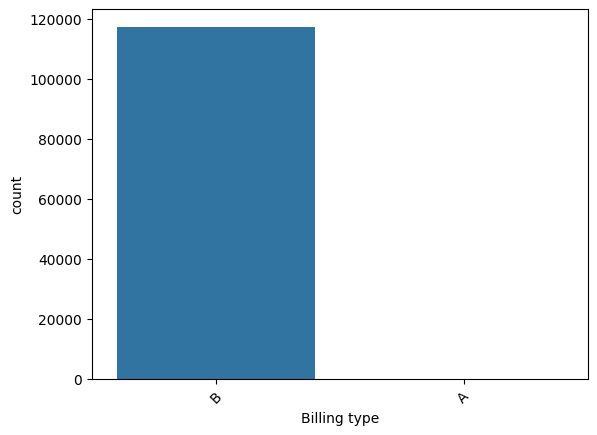

In [197]:
sns.countplot(data=df, x='Fac_Tipo')
plt.xlabel('Billing type')
plt.xticks(rotation=45)
plt.show()

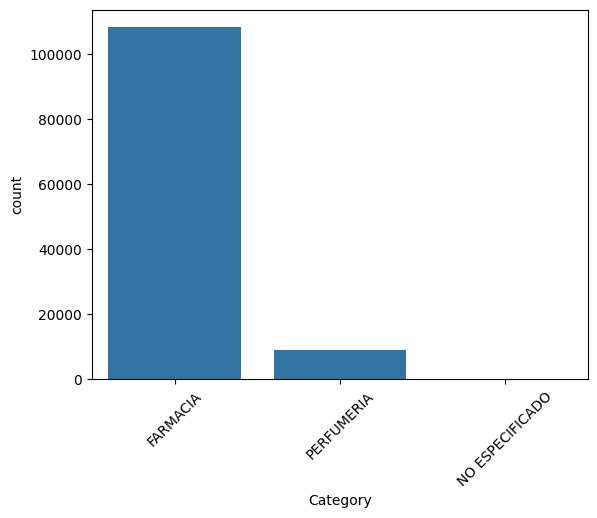

In [198]:
sns.countplot(data=df, x='Rubro')
plt.xlabel('Category')
plt.xticks(rotation=45)
plt.show()

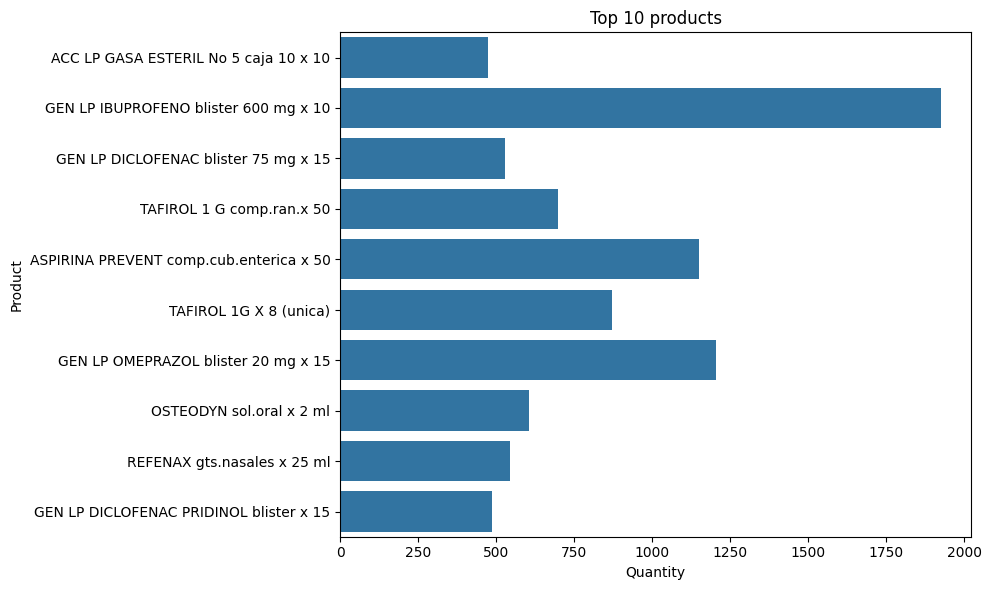

In [199]:
top_products = df['Producto'].value_counts().nlargest(10).index

plt.figure(figsize=(10, 6))
sns.countplot(data=df[df['Producto'].isin(top_products)],
              y='Producto')

plt.title(f'Top 10 products')
plt.xlabel('Quantity')
plt.ylabel('Product')
plt.tight_layout()
plt.show()


In [200]:
df['Producto']

0         ACTRON PEDIATRICO 4% susp.oral x 100 ml
1                   AMOXIDAL 500 mg comp.rec.x 21
2                   AMOXIDAL 500 mg comp.rec.x 21
3               MUELITA FORTE GEL gel pomo x 10 g
4                         DIOXAFLEX B12 comp.x 20
                           ...                   
117410                            COLGATE (unica)
117411                  TAFIROL 1 G comp.ran.x 50
117412              CICATRICURE GEL Gel NF x 30 g
117413                  LOUTEN T colirio x 2.5 ml
117414               MADOPAR HBS 125 mg cáps.x 30
Name: Producto, Length: 117398, dtype: object

In [201]:
df['brand'] = df['Producto'].str.split().str[0]

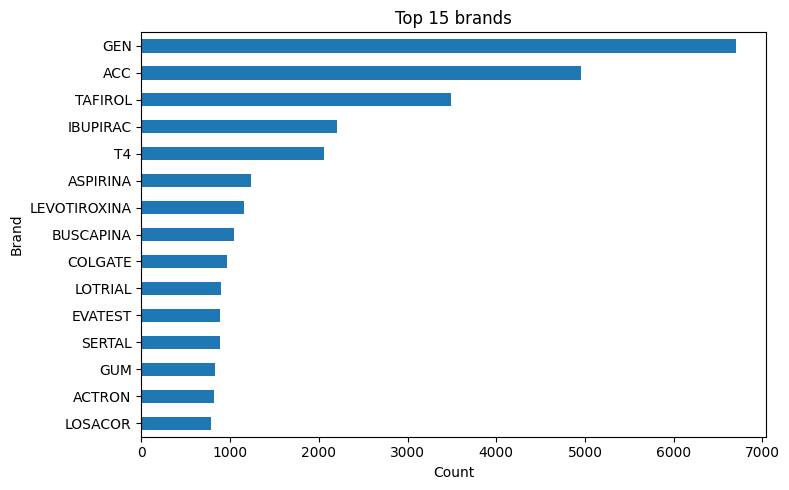

In [202]:
top_brands = df['brand'].value_counts().nlargest(15)

plt.figure(figsize=(8, 5))
top_brands.sort_values().plot(kind='barh')
plt.title('Top 15 brands')
plt.xlabel('Count')
plt.ylabel('Brand')
plt.tight_layout()
plt.show()

#### Observación: Inconsistencia en la estructura de nombres de productos
Al analizar el gráfico de "Top 10 Brands", se detecta que el método de extraer la primera palabra (str.split().str[0]) genera datos erróneos por tres razones principales:
- Nombres genéricos vs. marcas: Muchos productos comienzan con el principio activo (ej: LEVOTIROXINA, ASPIRINA, DIFENHIDRAMINA) en lugar de la marca comercial. Esto infla artificialmente el conteo de "marcas" que en realidad son drogas genéricas.
- Marcas compuestas: Marcas como ACC LP, GEN LP o T4 MONTPELLIER se cortan a la mitad, perdiendo su identidad real (quedando solo como ACC, GEN o T4).
- Posición variable de la marca: En algunos registros, la marca no es la primera palabra. Por ejemplo:

    - PROMO DERMAGLOS SOLAR... (La marca es Dermaglós, pero el código toma Promo).   
    - KIT FARMACOLOR... (La marca es Farmacolor, pero toma Kit).   
    - CEPILLO GUM... (La marca es GUM, pero toma Cepillo).   

In [203]:
def pharmacy_products(texto):
    if pd.isna(texto):
        return 'Unknown'
    
    texto = texto.lower()
    
    if 'comp' in texto:
        return 'Comprimido'
    elif 'gel' in texto:
        return 'Gel'
    elif 'susp' in texto:
        return 'Suspensión'
    elif 'colirio' in texto:
        return 'Colirio'
    elif 'jarabe' in texto:
        return 'Jarabe'
    elif 'caps' in texto or 'cáps' in texto:
        return 'Cápsula'
    else:
        return 'Otros'

df['form'] = df['Producto'].apply(pharmacy_products)

In [204]:
df['form'].value_counts()

form
Comprimido    52990
Otros         52845
Cápsula        7657
Gel            1796
Suspensión     1548
Colirio         427
Jarabe          135
Name: count, dtype: int64

In [205]:
df.groupby('Producto')['Precio'].std().sort_values(ascending=False).head(10)

Producto
AREXVY fco.a.liof.x1+disolv.x1                 189958.021297
FLORATIL 250 250 mg cáps.x 50                   55057.512253
MIRENA dispos.intrauterino x 1                  54804.697517
PARACETAMOL 1 GRAMO 1 g blíst.x 50 comp.x 8     51147.274245
EPAMIN cáps.x 90                                42744.301365
TRAYENTA comp.rec.x 30                          42619.426993
INFANRIX HEXA pvo.liof.+susp.iny.               41973.461362
ACCU-CHEK PERFORMA 50 tiras reactivas x 50      40802.105626
SHINGRIX liof.vial x 1 + ady. x 1               38919.707524
MAMADERA (unica)                                35496.760416
Name: Precio, dtype: float64

#### Problemas detectados:
- PARACETAMOL con desviación de $51,147
- MAMADERA con desviación de $35,496
- AREXVY con desviación de $189,958

In [206]:
# To see all the prices of Paracetamoldf[df['Producto'].str.contains('PARACETAMOL 1 GRAMO', case=False)]['Precio'].describe()
df[df['Producto'] == 'PARACETAMOL 1 GRAMO 1 g blíst.x 50 comp.x 8']

,Fecha,Fac_Tipo,Fac_Nun,Cant,Precio,Producto,Sub_Total,Rubro,Cobertura,Desc_Adic,Total_Cliente,IVA,Tasa_Iva,Total_Gravado,Total_sin_Gravar,brand,form
12008,2025-02-04 17:47:12,B,387287,3,1500.0,PARACETAMOL 1 GRAMO 1 g blíst.x 50 comp.x 8,4500.00,FARMACIA,0.0,0.0,4500.00,0.0,0,0.0,4500.00,PARACETAMOL,Comprimido
12837,2025-02-06 19:41:19,B,387802,1,1500.0,PARACETAMOL 1 GRAMO 1 g blíst.x 50 comp.x 8,1500.00,FARMACIA,0.0,0.0,1500.00,0.0,0,0.0,1500.00,PARACETAMOL,Comprimido
42674,2025-05-05 09:53:16,B,406131,8,77228.0,PARACETAMOL 1 GRAMO 1 g blíst.x 50 comp.x 8,1544.56,FARMACIA,0.0,0.0,1544.56,0.0,0,0.0,1544.56,PARACETAMOL,Comprimido
86916,2025-09-22 08:52:00,B,436902,8,100000.0,PARACETAMOL 1 GRAMO 1 g blíst.x 50 comp.x 8,2000.00,FARMACIA,0.0,0.0,2000.00,0.0,0,0.0,2000.00,PARACETAMOL,Comprimido


> Ventas totales: 4   
> Precio promedio: $45,057   
> Desviación estándar: $51,147   
> Rango: $1,500 - $100,000   
>
> El precio máximo ($100,000) es 66 veces mayor que el mínimo ($1,500).
> La mediana ($39,364) está muy alejada del mínimo, lo que indica que hay 2 valores normales ($1,500 cada uno) y 2 valores anómalos ($39,364 y $100,000).
> El Paracetamol genérico en Argentina cuesta entre $1,000 y $3,000 por caja. Un precio de $100,000 es imposible.
>
> **Conclusión:**   
> Hay un **error** de tipeo o error de carga.

In [207]:
# To delete or change the outlier
# df.loc[df['Precio'] > 10000, 'Precio'] = df['Precio'].median()

In [208]:
# To see all the prices of Mamadera
df[df['Producto'].str.contains('MAMADERA', case=False)][['Producto', 'Precio', 'Fecha']].sort_values('Precio')

,Producto,Precio,Fecha
23465,MAMADERA 250 ML./ TETINA DE SILICONA,3500.0,2025-03-12 16:25:01
11937,MAMADERA (unica),9000.0,2025-02-04 15:14:06
66726,MAMADERA FC+ 150 ml Control de Temperatura Cor...,22600.0,2025-07-22 18:37:19
23889,SCY 103/01 MAMADERA ANTICOLIC REFRESH 260 ML,28000.0,2025-03-13 18:20:24
101391,SCY 903/67 MAMADERA NATURAL RESPONSE 260ml DEC...,47200.0,2025-11-04 15:03:48
13650,MAMADERA (unica),59200.0,2025-02-10 10:12:24


> **Conclusión:**   
> No es un error, están agrupandas mamaderas básicas ($3,500) con mamaderas premium de tecnología avanzada ($47,200).

In [209]:
# To see all the prices of Arexvy
df[df['Producto'].str.contains('AREXVY', case=False)][['Fecha', 'Precio', 'Cobertura', 'Total_Cliente']].sort_values('Precio')

,Fecha,Precio,Cobertura,Total_Cliente
73103,2025-08-09 19:16:27,29000.00,0.000,29000.000
66275,2025-07-21 18:10:58,297641.21,119056.484,178584.726


> **Observaciones:**
>
> Al revisar los datos de AREXVY, se detecta una inconsistencia grave: una de las entradas registra un precio de lista de $29,000 con $0 de cobertura, mientras que la otra registra $297,641. Dado que el valor de mercado de esta vacuna es cercano a los $300,000, la entrada de $29,000 debe considerarse un error de registro o un dato incompleto, ya que no representa el valor real del bien ni existe una cobertura que justifique la diferencia.

In [210]:
df.groupby('form')['Desc_Adic'].mean()

form
Colirio        24.382265
Comprimido     13.214135
Cápsula        28.371637
Gel           204.311876
Jarabe          0.000000
Otros         145.703778
Suspensión     -4.164778
Name: Desc_Adic, dtype: float64

In [211]:
df['product_name'] = (df['Producto']
                       .str.lower()
                       .str.replace(r"[^a-z0-9 ]", "", regex=True))

In [212]:
df['product_name'].value_counts().head(30)

product_name
gen lp ibuprofeno blister 600 mg x 10                       1926
gen lp omeprazol blister 20 mg x 15                         1205
aspirina prevent compcubenterica x 50                       1150
tafirol 1g x 8 unica                                         870
tafirol 1 g compranx 50                                      699
osteodyn soloral x 2 ml                                      605
refenax gtsnasales x 25 ml                                   543
gen lp diclofenac blister 75 mg x 15                         530
gen lp diclofenac pridinol blister x 15                      488
acc lp gasa esteril no 5 caja 10 x 10                        473
corbis 5 mg comprecx 30                                      471
tafirol plus rapida accion cpsbl x 8                         471
alikal unica                                                 451
t4 montpellier 75 75 mcg compx 50                            446
acc lp tela antialergica 3m de 25 x 9 sracionador microp     438
t4 montpelli

In [213]:
df['Producto'].nunique()

7667

In [214]:
df['Producto'].dropna().drop_duplicates().sort_values().head(100)

88133      CHUP.MANZANITA(C/DIBUJO)T/SILIC.+3M RED - ES...
34267                                              (unica)
45585                        102 ANOS PLUS ANTIOXIDANTE 30
987                         102 ANOS SPORT MAX 30 SOBRES /
71060                       102 MAGNESIO CITRATO 30 COMP S
                               ...                        
104      ACC LP TELA ANTIALERGICA 3M de 2.5 x 9 S/Racio...
41094    ACC LP TELA ANTIALERGICA 3M de 5 x 9 C/Raciona...
76       ACC LP TELA ANTIALERGICA 3M de 5 x 9 S/Raciona...
224      ACC LP TELA ANTIALERGICA 3M de1.25 x 9 S/Racio...
3460     ACC LP TELA ANTIALERGICA 5 x 9 S/Racionador Mi...
Name: Producto, Length: 100, dtype: object

In [215]:
unique_products.to_csv('unique_products.csv',
                       index=False,
                       encoding='utf-8')

NameError: name 'unique_products' is not defined

In [ ]:
pharmaceutical_classifier = {
    'Salud Cardiovascular': ['alpertan', 'sartan', 'pril', 'olol', 'dipino', 'estatina', 'lipitor',
        'aspirina prevent', 'valsarfec', 'tervalon', 'ateronova', 'blokium', 'befol', 'furosemida',
        'torivas', 'aspirinetas', 'racorval', 'atenolol', 'enalapril', 'amlodipina', 'rovartal',
        'losartan', 'amloc', 'cardio', 'aldactone', 'lotrial', 'simultan', 'arteriosan', 'nebicor',
        'diurex', 'rosustatin', 'rovastane', 'epistal', 'minuslip', 'regulip', 'medocor', 'bisofec',
        'carrier', 'meplar', 'losacor', 'prinil', 'lipifen', 'dilcoran', 'acalix', 'rosufen', 'syncrocor',
        'ateroclar', 'aturen', 'daunlip', 'espironol', 'filten', 'pelmec', 'rosufec', 'aclusin',
        'bilip', 'bertel', 'nabila', 'corbis', 'diapresan', 'ixium', 'azecar', 'veraten', 'clopidogrel', 'astende',
        'acalik', 'atenix', 'indalten', 'glioten', 'diocam', 'meridian', 'dipemina', 'valpex', 'loctenk', 'zarator', 'loplac',
        'ilduc', 'bisopil', 'prisonil', 'sinlip', 'blavin', 'nivas', 'ultrex', 'vasotenal', 'antipresol', 'minicam', 'lasix',
        'sarval', 'atorvastatin', 'lostam', 'peptazol', 'vastarel', 'coracil', 'euretico', 'antiplaq', 'drimux',
        'ixacor', 'rosuvast', 'sistatin', 'tacardia', 'tanavat'],
    
    'Salud Mental / Sistema Nervioso': ['pisono', 'alplax', 'alprazolam', 'clonazepam', 'diazepam', 'fanter', 'lanx',
        'sertralina', 'fluoxetina', 'lexapro', 'psicoasten', 'quetiapina', 'somit', 'clonagin', 'asertral', 'trapax',
        'lamotrigina', 'zepam', 'latrigin', 'paxon', 'risperin', 'novo', 'asertral', 'asertral', 'clonagin', 'ivestron',
        'psicotil', 'rivotril', 'tiarix', 'ampliar', 'ultraneural', 'migral', 'clonagin', 'trastocir', 'duxetin', 'trastocir',
        'gavin', 'insertec', 'lextor', 'lexotanil', 'tranquinal', 'comenter', 'remizeral', 'aropax', 'quetiazic', 'discretal', 
        'neuryl', 'emotival', 'serubel', 'valium', 'carbamazepina', 'memantina', 'zoloft', 'depakene', 'elafax', 'neuristan', 'cabal',
        'inductal', 'epamin', 'mestinon', 'melatol', 'armonil', 'modaton', 'climatix'],

    'Salud Digestiva': ['alumpak', 'alverin', 'almax', 'omeprazol', 'pantoprazol', 'reflux', 'dulcolax', 'gastromax', 'rogastril', 'miopropan', 'genoprazol', 'barex',
        'lanzoprazol', 'aci-tip', 'agarol', 'buscapina', 'bagohepat', 'lactulon', 'sinulcus', 'peptazol', 'esoprazol',
        'chofitol', 'bismuto', 'oligoplex', 'mylanta', 'taural', 'bicarbonato', 'qg5', 'sincerum', 'mudantil',
        'alikal', 'sertal', 'regulane', 'axiomat', 'loperamida', 'ulcozol', 'lactulon', 'mutum', 'zoltenk', 'mebutar',
        'suerox', 'vorpix', 'aziatop', 'uvasal', 'rennie', 'hepatalgina', 'aglucide', 'acimed', 'esomepra', 'dexopral', 
        'biletan', 'agiolax', 'reliveran', 'malvahp', 'genoprazol', 'gastromax', 'enterogermina', 'sucralfato', 'lorebil', 'dulcolax'],

    'Salud Sexual / Urología': ['nafil', 'dalafil', 'sildenafil', 'tadalafil'],

    'Oftalmología': ['alphagan', 'ofta', 'colirio', 'timolol', 'latanoprost', 'lágrimas', 'idena', 'latlas', 'coltix', 'isis', 'flarex'
        'gotas', 'tobrex', 'gatidex', 'soloftlmica', 'tobradex', 'sensu', 'natax', 'fotamicin',
        'restasis', 'systane', 'aucic', 'irix', 'opti free', 'gota pc', 'timed', 'quidex', 'coltix', 'latlas', 'gotabiotic', 'ciriax'],

    'Antibióticos': ['cilina', 'micina', 'floxacino', 'cicli', 'cef', 'amoxi', 
        'clavulanico', 'ceporexin', 'triamid', 'debril', 'nabratin', 'macril', 'bactrim',
        'poviral', 'bactifren', 'leflumax', 'nixoran', 'ivercass', 'azibiotic', 'flagyl', 'cronopen', 'bactifren'],

    'Antimicóticos': ['fluconazol', 'fangan'],

    'Analgésicos / Antiinflamatorios': ['profeno', 'fenaco', 'coxib', 'paracetamol', 'aspirina', 'fungocina', 'unesia', 'dorixina',
        'dol', 'clonixinato', 'mejoral', 'geniol', 'meloxicam', 'muelita', 'fabogesic', 'actron', 'next',
        'dioxaflex', 'ketorolac', 'tafirol', 'naprux', 'diclofenac', 'artrosil', 'anaflex', 'procetoken', 'liparex', 'gargaletas',
        'prontal', 'ibu', 'evanol', 'diclomar', 'flogocox', 'bengue', 'ponstil', 'tetralgin', 'sinalgico'],

    'Salud Respiratoria / Antialérgicos': ['tadina', 'rizina', 'nasona', 'terol', 'ambroxol', 'mucol', 'frevia', 'alernix', 'aerotina', 'alercas', 'acemuk', 'aerius',
        'frenadol', 'antigripal', 'ventolin', 'athos', 'relvar', 'neumocort', 'nasal', 'lukast', 'aliviatos', 'caramelos', 'refrianex',
        'asmavitan', 'seretide', 'refenax', 'lidil', 'cedric', 'flutivent', 'collubiazol', 'pulmocler', 'salbutral', 'cetizine'],

    'Antialérgicos': ['dexalergin', 'hexaler', 'frenaler', 'difenhidramina', 'cortipyren'],

    'Higiene y Cuidado Personal': ['shampoo', 'acondicionador', 'jabon', 'desodorante', 'axe', 'st ives', 'fluordent', 'plac out', 'dentilac', 'evagina', 'trim', 'gel',
        'dove', 'colgate', 'pasta dental', 'cepillo', 'hilo dental', 'gillette', 'listerine', 'venus',
        'enjuague bucal', 'protector solar', 'neutrogena', 'dermaglos', 'ensure', 'nopucid', 'sapolan',
        'aderma', 'aveno', 'cerave', 'vichy', 'la roche', 'cicatricure', 'OB', 'issue', 'alcohol',
        'lactacyd', 'asepxia', 'biferdil', 'capilatis', 'cutex', 'idi', 'medicasp', 'ortodoncia',
        'siempre libre', 'always', 'carefree', 'softpicks', 'rexona', 'cepillo', 'glicerina',
        'close', 'proxa', 'johnson', 'carey', 'pantene', 'nivea', 'hinds', 'tresemmé', 'esmalte',
        'labello', 'clear', 'corega', 'flossers', 'discos', 'farmacolor', 'esmalte', 'cortauas',
        'dermagls', 'eumicel', 'libre', 'listerine', 'gum', 'tresemme', 'veet', 'ciel', 'difusor',
        'escofina', 'eva gina', 'toallitas', 'crema ordee', 'sensodyne', 'piroctol', 'desodorante', 'algodón'],

    'Accesorios y Dispositivos Médicos': ['pañal', 'huggies', 'pampers', 'toalla', 'algodon', 'jeringa', 
        'aguja', 'preservativo', 'condon', 'test', 'termometro', 'soft', 'comodin', 'inconti',
        'curitas', 'accesorio', 'barbijo', 'maxx', 'broche', 'espermicida'],

    'Nutrición y Suplementos': ['magnesio', 'vitamina', 'suplemento', 'ensure', 'pediasure', 
        'bagovit', 'centrum', 'berocca', 'supradyn', 'acifol', 'hierro', 'nutrilon', 'ostelin', 'vitalix',
        'calcio', 'soloral', 'osteodyn', 'omega', 'chia', 'colageno', 'tapones', 'dbi', 'tanvimil', 'ajo',
        'artrostop', 'curflex', 'b12', 'becozym', 'redoxon', 'bernafolic', 'glucerna', 'magnesiano',
        'devisal', 'sterogyl', 'raquiferol', 'oravil', 'larotabe', 'quelat', 'siderblut', 'gadoferol', 'valcatil', 'allopurinol'],

    'Diabetes y Endocrino': ['metformina', 'insulina', 'glibenclamida', 'levotiroxina', 'glucophage', 'danantizol', 'nexdia',
        't4', 'glucosa', 'glucogood', 'forxiga', 'islotin', 'diamicron', 'aglucide', 'siaglix', 'zomarist', 'imecot', 'glemaz'],

    'Material de Curación': ['guante', 'gasa', 'iruxol', 'iodopovidona', 'estéril', 'envase', 'curita', 'venda', 'aplicacion',
        'antialérgica', 'tela', 'merthiolate', 'anestésico', 'ox', 'fisiológica', 'alibour', 'fisiologica', 'hipoalergic', 'curita', 'tubos'],

    'Gripe': ['qura', 'rhinal', 'ventonil'],

    'Dermatología': ['paldar', 'megacistin', 'deralbine', 'vaselina', 'empecid', 'mupax', 'keratopic', 'louten', 'erisol', 'sinamida', 'ordee',
        'cremtotal', 'hipoglos', 'diabet', 'betacort', 'factor', 'platsula', 'perpiel', 'piecidex', 'dermexane', 'caladryl', 'salil', 'teatrical',
        'dermagls', 'dermagls', 'dermexane', 'caladryl', 'gentaderm', 'filtres', 'fenosane', 'procetoken', 'crx', 'dermagls solar', 'vitacortil'],

    'Ginecológico / Salud Femenina': ['fucsia', 'diva', 'colpofilin', 'vagisil', 'ovufem', 'elektra', 'umma', 'levogest', 'isis free', 'yaz', 'kala', 'ginkan', 'vagilen',
                                      'damsella', 'norgestrel', 'divina', 'cerazette', 'amapoli', 'miranda', 'nor', 'fenogynol', 'camelia', 'kali', 'ovata',
                                      'gadofem', 'torgyn', 'colpoestriol', 'femiden', 'damsel', 'slinda', 'ginelea', 'ob', 'diane', 'isis'],

    'Fragancia': ['cuore', 'pepas', 'paco'],

    'Vascular': ['daflon'],

    'Urología': ['reduprost', 'urocont', 'prostoklar', 'duodart', 'sulos', 'magnus', 'urifex', 'finasterin', 'uralos', 'minocass'],

    'Otorrino': ['meniex', 'otosan'],

    'Reumatología': ['brek', 'marvil', 'asotrex'],

    'Corticoides': ['deltisona', 'corticas', 'cronocorteroid']
}

In [ ]:
def assign_category(name):
    name = str(name).lower()
    for category, words in pharmaceutical_classifier.items():
        for word in words:
            if word in name:
                return category
    return 'Otros'

df['groups'] = df['Producto'].apply(assign_category)

In [ ]:
mask = df['groups'].isin(['Otros', 'Unknown'])

In [ ]:
df.loc[mask, 'groups'] = df.loc[mask, 'Producto'].apply(assign_category)

In [ ]:
print(df['groups'].value_counts())

groups
Otros                                 23812
Salud Cardiovascular                  15106
Analgésicos / Antiinflamatorios       14925
Higiene y Cuidado Personal            10427
Salud Digestiva                        9053
Nutrición y Suplementos                6371
Salud Mental / Sistema Nervioso        5915
Salud Respiratoria / Antialérgicos     5322
Material de Curación                   5116
Diabetes y Endocrino                   3684
Ginecológico / Salud Femenina          3466
Accesorios y Dispositivos Médicos      3207
Antibióticos                           2924
Dermatología                           2792
Oftalmología                           2439
Urología                                799
Antialérgicos                           716
Gripe                                   591
Corticoides                             184
Antimicóticos                           144
Otorrino                                132
Fragancia                                98
Salud Sexual / Urología  

In [ ]:
df.loc[df['groups'] == 'Otros', ['product_name', 'groups']].head(60)

,product_name,groups
135,platsula crx 30 g,Otros
226,platsula crx 30 g,Otros
279,otoclean gotas oticas gtsticas x 10 ml,Otros
511,gen lp salbutamol gotas gotas x 20 ml,Otros
664,promocional dermagls solar f50 em 380ml fps50 ...,Otros
839,promocional dermagls solar f30 em 380 ml fps30...,Otros
865,antihemorroidal denver farma crrectal x 20 g,Otros
959,micoclin vx 6,Otros
972,audax cpsx 30,Otros
1002,platsula crx 100 g,Otros


#### Variables numéricas

Varias variables se encontraban almacenadas como tipo object a pesar de representar valores numéricos. Se procedió a su conversión a tipo numérico y los valores no convertibles a NaN para su posterior tratamiento.

In [ ]:
numerical_variables = df.select_dtypes(include=['int64', 'float64'])
numerical_variables

,Fac_Nun,Cant,Precio,Sub_Total,Cobertura,Desc_Adic,Total_Cliente,IVA,Tasa_Iva,Total_Gravado,Total_sin_Gravar
0,379923,1,9344.00,9344.00,0.00,0.0,9344.00,0.000000,0,0.0000,9344.00
1,379924,1,8174.96,8174.96,3032.85,0.0,5142.11,0.000000,0,0.0000,8174.96
2,379925,1,8174.96,8174.96,5318.10,0.0,2856.86,0.000000,0,0.0000,8174.96
3,379926,1,8086.82,8086.82,0.00,0.0,8086.82,0.000000,0,0.0000,8086.82
4,379927,1,26750.12,26750.12,0.00,0.0,26750.12,0.000000,0,0.0000,26750.12
...,...,...,...,...,...,...,...,...,...,...,...
117410,455861,1,5000.00,5000.00,0.00,0.0,5000.00,0.000000,0,0.0000,5000.00
117411,455862,1,13641.20,13641.20,5808.98,0.0,7832.22,0.000000,0,0.0000,13641.20
117412,455863,1,16000.00,16000.00,0.00,0.0,16000.00,2776.859504,21,13223.1405,0.00
117413,455864,1,36758.39,36758.39,14703.36,0.0,22055.03,0.000000,0,0.0000,36758.39


Variables numéricas son: `Fac_Nun`, `Cant`, `Precio`, `Sub_Total`, `Cobertura`, `Desc_Adic`, `Total_Cliente`, `IVA`, `Tasa_Iva`, `Total_Gravado`, `Total_sin_Gravar`.

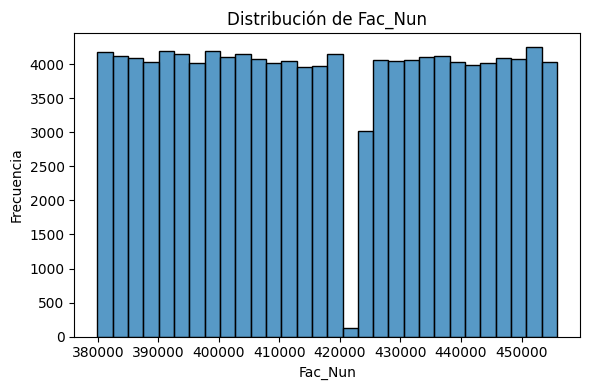

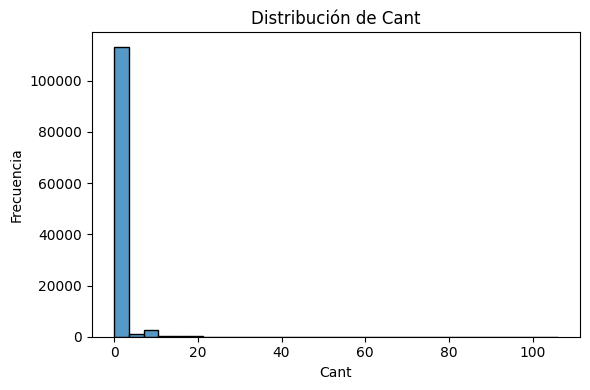

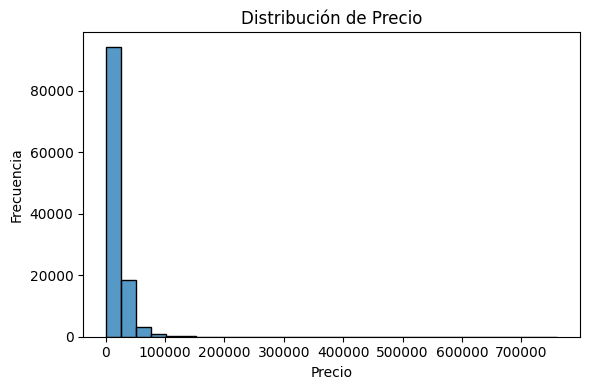

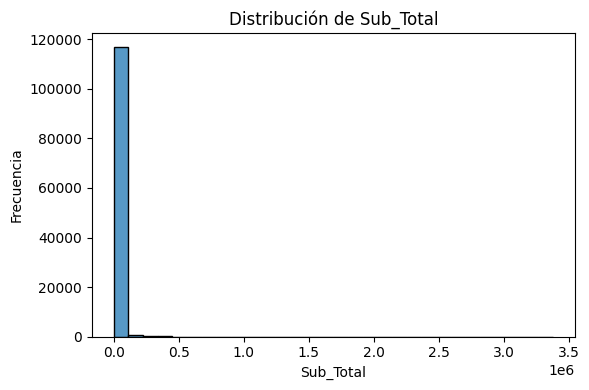

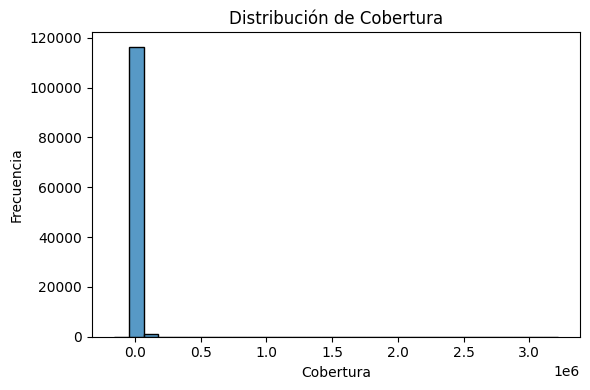

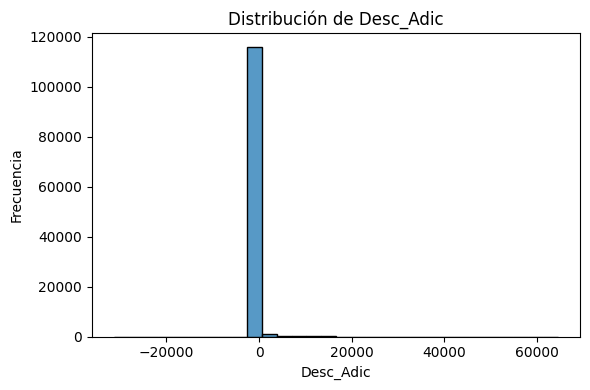

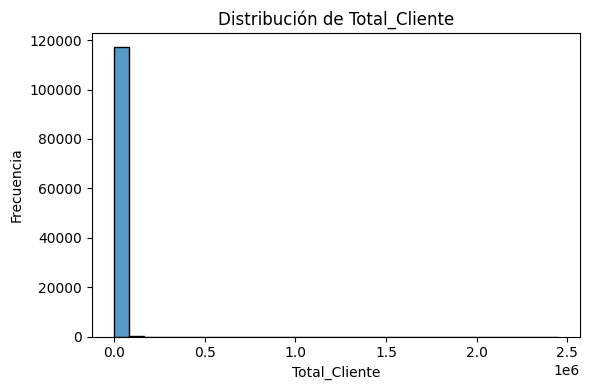

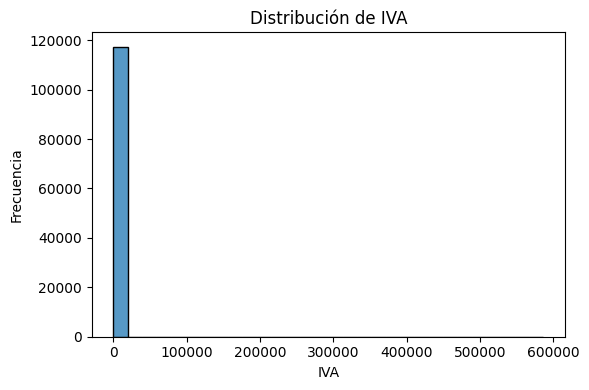

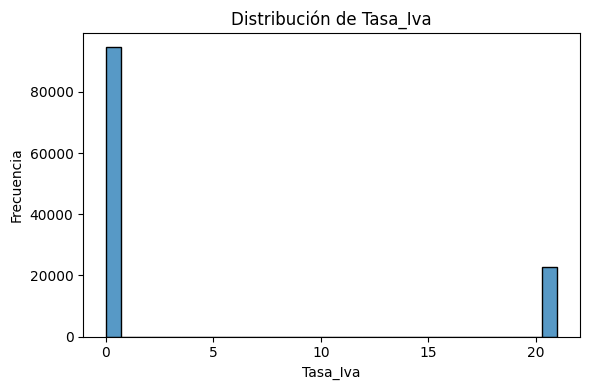

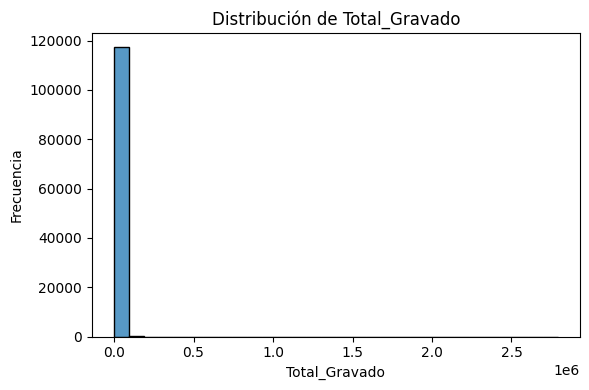

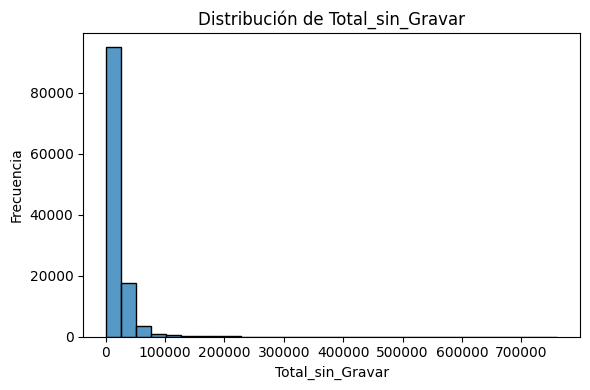

In [ ]:
for col in numerical_variables.columns:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], bins=30)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

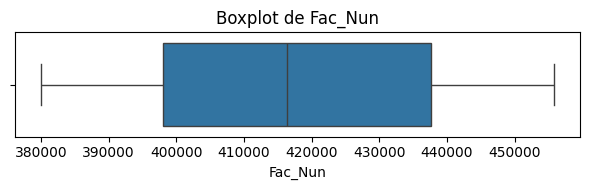

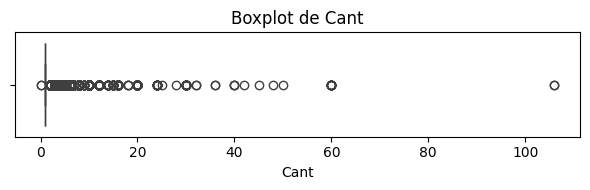

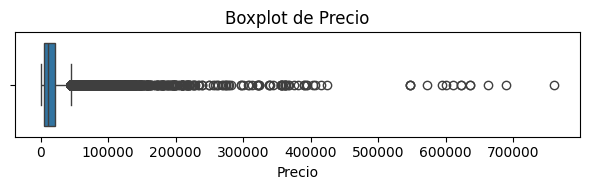

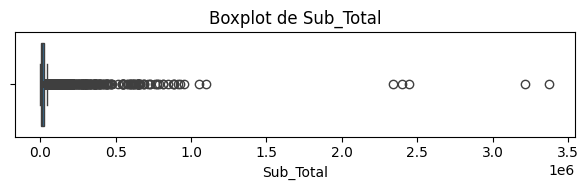

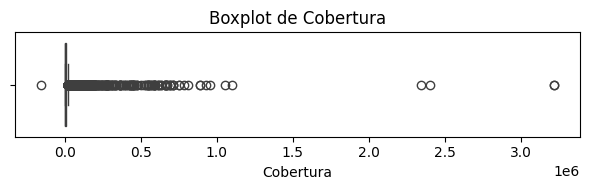

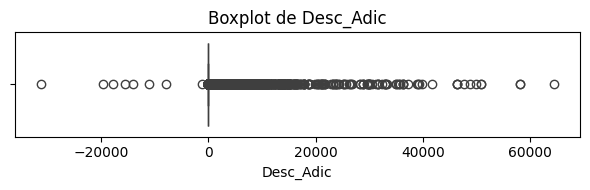

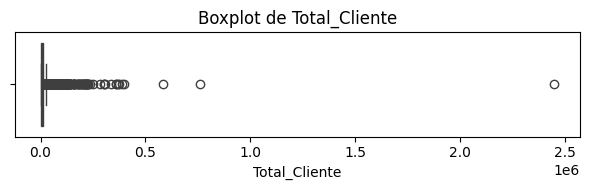

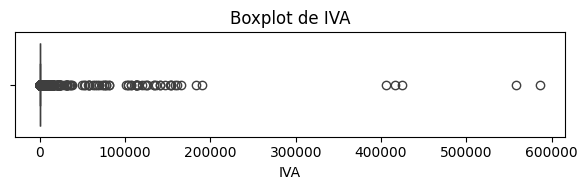

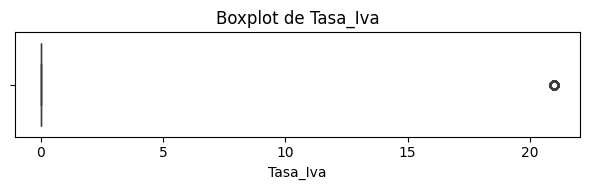

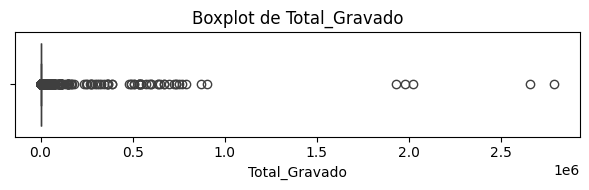

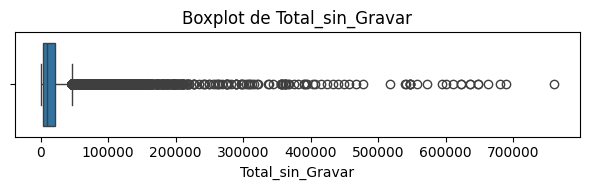

In [ ]:
for col in numerical_variables.columns:
    plt.figure(figsize=(6, 2))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot de {col}')
    plt.tight_layout()
    plt.show()

In [ ]:
df.loc[df['Cant'] > 50, ['Fecha', 'Fac_Tipo', 'Producto', 'Cant']]

,Fecha,Fac_Tipo,Producto,Cant
2190,2025-01-07 16:16:24,B,ENSURE ADVANCE LIQUIDO frutilla bot. x 220 ml,60
3001,2025-01-09 15:36:43,B,ENSURE PLUS vainilla env.x 220 ml,60
4521,2025-01-13 18:13:59,B,ENSURE ADVANCE LIQUIDO frutilla bot. x 220 ml,60
14340,2025-02-12 14:42:34,B,ENSURE PLUS vainilla env.x 220 ml,60
16565,2025-02-18 16:03:58,B,ENSURE PLUS FRUTILLA 220 ML,60
25463,2025-03-17 17:38:05,B,ENSURE ADVANCE LIQUIDO café botella x 220 ml,60
36775,2025-04-16 15:44:30,B,ENSURE PLUS vainilla env.x 220 ml,60
38911,2025-04-23 15:54:06,B,ENSURE PLUS frutilla env.x 220 ml,60
47946,2025-05-19 15:59:52,B,ENSURE PLUS frutilla env.x 220 ml,60
48730,2025-05-21 15:02:04,B,ENSURE PLUS vainilla env.x 220 ml,60


In [ ]:
df.loc[df['Precio'] > 500000]

,Fecha,Fac_Tipo,Fac_Nun,Cant,Precio,Producto,Sub_Total,Rubro,Cobertura,Desc_Adic,Total_Cliente,IVA,Tasa_Iva,Total_Gravado,Total_sin_Gravar,brand,form,product_name,groups
4453,2025-01-13 16:19:18,B,382628,1,547557.61,MIRENA dispos.intrauterino x 1,547557.61,FARMACIA,547557.61,0.0,0.00,0.0,0,0.0,547557.61,MIRENA,Otros,mirena disposintrauterino x 1,Otros
5224,2025-01-15 13:53:53,B,383086,1,547557.61,MIRENA dispos.intrauterino x 1,547557.61,FARMACIA,547557.61,0.0,0.00,0.0,0,0.0,547557.61,MIRENA,Otros,mirena disposintrauterino x 1,Otros
15357,2025-02-14 18:35:58,B,389421,1,547557.61,MIRENA dispos.intrauterino x 1,547557.61,FARMACIA,547557.61,0.0,0.00,0.0,0,0.0,547557.61,MIRENA,Otros,mirena disposintrauterino x 1,Otros
33524,2025-04-08 10:43:50,B,400545,1,573034.37,KYLEENA dispos.intrauterino x1,573034.37,FARMACIA,573034.37,0.0,0.00,0.0,0,0.0,573034.37,KYLEENA,Otros,kyleena disposintrauterino x1,Otros
47931,2025-05-19 15:54:43,B,409483,1,594236.64,MIRENA dispos.intrauterino x 1,594236.64,FARMACIA,594236.64,0.0,0.00,0.0,0,0.0,594236.64,MIRENA,Otros,mirena disposintrauterino x 1,Otros
71753,2025-08-06 13:12:39,B,427492,1,600093.42,AJOVY 225 mg jga.prell. x 1,600093.42,FARMACIA,591108.57,0.0,8984.85,0.0,0,0.0,600093.42,AJOVY,Otros,ajovy 225 mg jgaprell x 1,Nutrición y Suplementos
71969,2025-08-06 18:57:03,B,427618,1,623092.78,MIRENA dispos.intrauterino x 1,623092.78,FARMACIA,623092.78,0.0,0.00,0.0,0,0.0,623092.78,MIRENA,Otros,mirena disposintrauterino x 1,Otros
72556,2025-08-08 15:10:42,B,427980,1,635554.63,MIRENA dispos.intrauterino x 1,635554.63,FARMACIA,635554.63,0.0,0.00,0.0,0,0.0,635554.63,MIRENA,Otros,mirena disposintrauterino x 1,Otros
82164,2025-09-05 19:34:38,B,433986,1,610895.10,AJOVY 225 mg jga.prell. x 1,610895.10,FARMACIA,610895.10,0.0,0.00,0.0,0,0.0,610895.10,AJOVY,Otros,ajovy 225 mg jgaprell x 1,Nutrición y Suplementos
92484,2025-10-08 17:55:56,B,440377,1,622502.11,AJOVY 225 mg jga.prell. x 1,622502.11,FARMACIA,610895.10,0.0,11607.01,0.0,0,0.0,622502.11,AJOVY,Otros,ajovy 225 mg jgaprell x 1,Nutrición y Suplementos


##### Observaciones:
> Se filtraron las variables **cantidad y precio** con el objetivo de identificar posibles outliers. En el análisis de la variable **cantidad**, se observó que los valores extremos corresponden a información real y relevante, principalmente asociada a productos de alta rotación como alimentos para bebés y productos dietéticos para personas con diabetes. Por este motivo, se decidió **no eliminar** estos registros.   
>
> Al analizar la variable **precio**, se detectó que los valores más elevados están mayoritariamente asociados a productos como dispositivos intrauterinos o jeringas precargadas. Mediante un estudio de precios se verificó que dichos valores corresponden al precio real de mercado de estos productos, por lo que se decidió **conservar estos datos**.   

In [ ]:
df['Cobertura'].value_counts()

Cobertura
0.000        68024
5823.310       257
8007.280       238
8538.770       229
4284.820       221
             ...  
64666.190        1
11217.715        1
36589.322        1
12146.372        1
22983.016        1
Name: count, Length: 23021, dtype: int64

In [ ]:
df[df['Cobertura'] > 0.0]

,Fecha,Fac_Tipo,Fac_Nun,Cant,Precio,Producto,Sub_Total,Rubro,Cobertura,Desc_Adic,Total_Cliente,IVA,Tasa_Iva,Total_Gravado,Total_sin_Gravar,brand,form,product_name,groups
1,2025-01-01 01:59:21,B,379924,1,8174.96,AMOXIDAL 500 mg comp.rec.x 21,8174.96,FARMACIA,3032.850,0.0,5142.110,0.0,0,0.0,8174.96,AMOXIDAL,Comprimido,amoxidal 500 mg comprecx 21,Antibióticos
2,2025-01-01 02:01:59,B,379925,1,8174.96,AMOXIDAL 500 mg comp.rec.x 21,8174.96,FARMACIA,5318.100,0.0,2856.860,0.0,0,0.0,8174.96,AMOXIDAL,Comprimido,amoxidal 500 mg comprecx 21,Antibióticos
10,2025-01-02 08:20:50,B,379932,1,35517.30,VERATEN UD 40 mg cáps.lib.ext.x 30,35517.30,FARMACIA,28654.800,0.0,6862.500,0.0,0,0.0,35517.30,VERATEN,Cápsula,veraten ud 40 mg cpslibextx 30,Salud Cardiovascular
11,2025-01-02 08:27:00,B,379933,1,23864.21,ASERTRAL 50 mg comp.ran.x 30,23864.21,FARMACIA,9545.680,0.0,14318.530,0.0,0,0.0,23864.21,ASERTRAL,Comprimido,asertral 50 mg compranx 30,Salud Mental / Sistema Nervioso
26,2025-01-02 09:07:05,B,379939,1,45296.37,PISONO 5 mg comp.rec.x 30,45296.37,FARMACIA,29311.670,0.0,15984.700,0.0,0,0.0,45296.37,PISONO,Comprimido,pisono 5 mg comprecx 30,Salud Mental / Sistema Nervioso
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117402,2025-12-23 10:03:35,B,455857,2,18005.59,LEVOTIROXINA GSK 75 mcg comp.x 50,36011.18,FARMACIA,17077.540,0.0,18933.640,0.0,0,0.0,36011.18,LEVOTIROXINA,Comprimido,levotiroxina gsk 75 mcg compx 50,Diabetes y Endocrino
117403,2025-12-23 10:14:44,B,455858,1,61861.72,DAPAX 10 mg comp.rec.x 30,61861.72,FARMACIA,43303.204,0.0,18558.516,0.0,0,0.0,61861.72,DAPAX,Comprimido,dapax 10 mg comprecx 30,Otros
117404,2025-12-23 10:14:44,B,455858,1,93412.40,SIAGLIX 100 mg comp.rec.x 30,93412.40,FARMACIA,65388.680,0.0,28023.720,0.0,0,0.0,93412.40,SIAGLIX,Comprimido,siaglix 100 mg comprecx 30,Diabetes y Endocrino
117411,2025-12-23 10:25:57,B,455862,1,13641.20,TAFIROL 1 G comp.ran.x 50,13641.20,FARMACIA,5808.980,0.0,7832.220,0.0,0,0.0,13641.20,TAFIROL,Comprimido,tafirol 1 g compranx 50,Analgésicos / Antiinflamatorios


In [ ]:
df = df.copy()

In [ ]:
# To create new column (binary)
df['has_coverage'] = (df['Cobertura'] > 0).astype(int)

In [ ]:
# Calculate coverage percentage
df['coverage_percentage'] = (df['Cobertura'] / df['Sub_Total']).fillna(0)

In [ ]:
# To narrow down rare values
df.loc[df['coverage_percentage'] > 1, 'coverage_percentage'] = 1

In [ ]:
# Amount paid by the customer
df['paid_by_customer'] = df['Sub_Total'] - df['Cobertura']

> La variable `Cobertura` representa el importe cubierto por obras sociales o prepagas. Dado que presenta una gran dispersión de valores y depende directamente del precio del producto, se decidió transformarla en nuevas variables más informativas.   
>
> Se creó una variable binaria (has_coverage) para identificar si una venta posee o no cobertura, y una variable continua (coverage_percentage) que indica el porcentaje del subtotal cubierto. Estas transformaciones permiten una mejor interpretación durante el análisis exploratorio y mejoran el desempeño del modelo de predicción.

In [ ]:
df.columns

Index(['Fecha', 'Fac_Tipo', 'Fac_Nun', 'Cant', 'Precio', 'Producto',
       'Sub_Total', 'Rubro', 'Cobertura', 'Desc_Adic', 'Total_Cliente', 'IVA',
       'Tasa_Iva', 'Total_Gravado', 'Total_sin_Gravar', 'brand', 'form',
       'product_name', 'groups', 'has_coverage', 'coverage_percentage',
       'paid_by_customer'],
      dtype='object')

In [ ]:
df['coverage_percentage'].value_counts()

coverage_percentage
0.000000    68024
1.000000     8039
0.500000     5085
0.400000     2974
0.600000     2075
            ...  
0.680037        1
0.901620        1
0.823423        1
0.400000        1
0.650535        1
Name: count, Length: 15236, dtype: int64

In [ ]:
df_group['groups_encoded'] = df_group['groups'].astype('category').cat.codes

In [ ]:
df_group['Fecha'] = pd.to_datetime(df_group['Fecha'])

In [ ]:
# To create sales time series
df_group = df_group.sort_values(['groups', 'Fecha'])

In [ ]:
# To create calendar features
df_group['date'] = pd.to_datetime(df_group['Fecha'])
df_group['week_day'] = df_group['Fecha'].dt.dayofweek
df_group['month'] = df_group['Fecha'].dt.month
df_group['month_day'] = df_group['Fecha'].dt.day
df_group['weekend'] = df_group['week_day'].isin([5,6]).astype(int)
df_group['beginning_month'] = (df_group['month_day'] <= 10).astype(int)

In [ ]:
# To create features from the past
for lag in [1, 7, 14, 30]:
    df_group[f'cant_lag_{lag}'] = df_group.groupby('groups')['Cant'].shift(lag)

In [ ]:
# The average of the last 7 and 30 days
df_group['rolling_7'] = df_group.groupby('groups')['Cant'].transform(lambda x: x.rolling(7).mean())
df_group['rolling_30'] = df_group.groupby('groups')['Cant'].transform(lambda x: x.rolling(30).mean())

In [ ]:
df_group.head(10)

,Fecha,groups,Cant,date,week_day,month,month_day,weekend,beginning_month,cant_lag_1,cant_lag_7,cant_lag_14,cant_lag_30,rolling_7,rolling_30,groups_encoded
1999,2025-01-07 19:14:11,Accesorios y Dispositivos Médicos,1,2025-01-07 19:14:11,1,1,7,0,1,NaN,NaN,NaN,NaN,NaN,NaN,0
2006,2025-01-07 19:20:48,Accesorios y Dispositivos Médicos,1,2025-01-07 19:20:48,1,1,7,0,1,1.0,NaN,NaN,NaN,NaN,NaN,0
2019,2025-01-07 19:36:49,Accesorios y Dispositivos Médicos,1,2025-01-07 19:36:49,1,1,7,0,1,1.0,NaN,NaN,NaN,NaN,NaN,0
2025,2025-01-07 19:44:35,Accesorios y Dispositivos Médicos,1,2025-01-07 19:44:35,1,1,7,0,1,1.0,NaN,NaN,NaN,NaN,NaN,0
2090,2025-01-08 09:48:17,Accesorios y Dispositivos Médicos,2,2025-01-08 09:48:17,2,1,8,0,1,1.0,NaN,NaN,NaN,NaN,NaN,0
2114,2025-01-08 10:16:21,Accesorios y Dispositivos Médicos,1,2025-01-08 10:16:21,2,1,8,0,1,2.0,NaN,NaN,NaN,NaN,NaN,0
2140,2025-01-08 11:07:43,Accesorios y Dispositivos Médicos,1,2025-01-08 11:07:43,2,1,8,0,1,1.0,NaN,NaN,NaN,1.142857,NaN,0
2160,2025-01-08 11:52:10,Accesorios y Dispositivos Médicos,1,2025-01-08 11:52:10,2,1,8,0,1,1.0,1.0,NaN,NaN,1.142857,NaN,0
2188,2025-01-08 12:26:16,Accesorios y Dispositivos Médicos,1,2025-01-08 12:26:16,2,1,8,0,1,1.0,1.0,NaN,NaN,1.142857,NaN,0
2198,2025-01-08 12:43:43,Accesorios y Dispositivos Médicos,1,2025-01-08 12:43:43,2,1,8,0,1,1.0,1.0,NaN,NaN,1.142857,NaN,0


In [ ]:
# To remove NaN
df_group = df_group.dropna()

In [ ]:
# Split
last_date = df_group['Fecha'].max()
cut_off_date = last_date - pd.Timedelta(days=30)

train = df_group[df_group['Fecha'] <= cut_off_date]
test = df_group[df_group['Fecha'] > cut_off_date]

In [217]:
features = [
    'groups_encoded',
    'week_day', 
    'month', 
    'month_day', 
    'weekend', 
    'beginning_month',
    'cant_lag_1', 
    'cant_lag_7', 
    'cant_lag_14', 
    'cant_lag_30',
    'rolling_7', 
    'rolling_30'
]

X_train = train[features]
y_train = train['Cant']

X_test = test[features]
y_test = test['Cant']

In [218]:
model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8
)

In [219]:
model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [220]:
y_pred = model.predict(X_test)

In [221]:
mae = mean_absolute_error(y_test, y_pred)
mae

0.6387505531311035

In [223]:
rmse = np.sqrt(((y_test - y_pred)**2).mean())
rmse

np.float64(1.8527019774825269)

MAE: 0.64 unidades
- En promedio, el modelo se equivoca por menos de una unidad (caja/frasco) por día y por grupo farmacéutico.
- El modelo ha capturado muy bien el "ritmo" de ventas de la farmacia.

RMSE: 1.85 unidades
- Un RMSE de 1.85 frente a un MAE de 0.64 sugiere que la mayoría de los días el modelo es casi exacto, pero hay algunos días puntuales donde la diferencia es de unas 2 o 3 unidades (posiblemente por ventas inusuales o falta de stock).

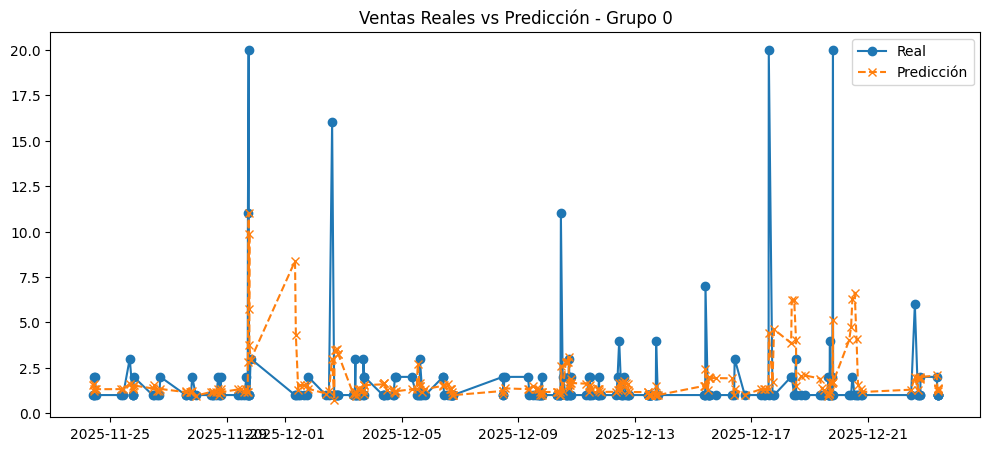

In [224]:
grupo_ejemplo = test['groups_encoded'].iloc[0]
test_subset = test[test['groups_encoded'] == grupo_ejemplo]
pred_subset = model.predict(test_subset[features])

plt.figure(figsize=(12, 5))
plt.plot(test_subset['Fecha'], test_subset['Cant'], label='Real', marker='o')
plt.plot(test_subset['Fecha'], pred_subset, label='Predicción', linestyle='--', marker='x')
plt.title(f'Ventas Reales vs Predicción - Grupo {grupo_ejemplo}')
plt.legend()
plt.show()

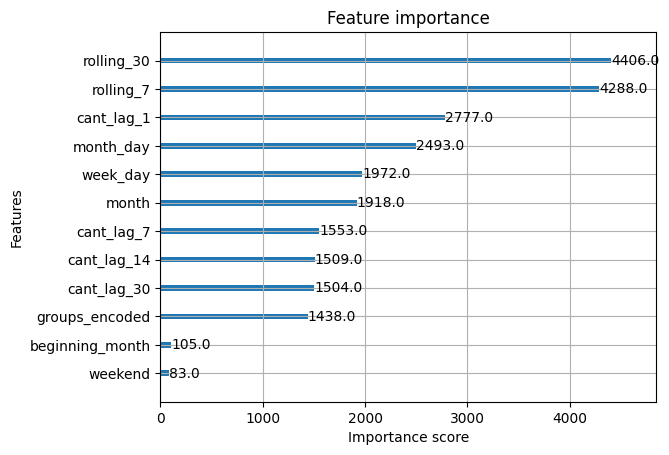

In [226]:
xgb.plot_importance(model, importance_type='weight', max_num_features=12)
plt.show()

### Modelos

Basados en Árboles: 
- XGBoost 
- LightGBM 
- CatBoost

Series Temporales: 
- Prophet (de Facebook/Meta) 
- ARIMA / SARIMA


In [ ]:
df_forecast = df.groupby(['Fecha', 'groups']).agg({
    'Cant': 'sum',
    'Precio': 'mean'  # Precio promedio del día
}).reset_index()

In [ ]:
df_forecast = df_forecast.sort_values(by=['groups', 'Fecha'])

In [ ]:
# Ventas de días anteriores
for i in [1, 7, 14, 30]:
    df_forecast[f'ventas_lag_{i}'] = df_forecast.groupby('groups')['Cant'].shift(i)

# Crear "Rolling Means" (Promedios móviles - suavizan la curva)
df_forecast['promedio_7dias'] = df_forecast.groupby('groups')['Cant'].transform(lambda x: x.rolling(window=7).mean())

# Extraer variables del calendario
df_forecast['mes'] = df_forecast['Fecha'].dt.month
df_forecast['dia_semana'] = df_forecast['Fecha'].dt.dayofweek
df_forecast['es_fin_de_semana'] = df_forecast['dia_semana'].isin([5, 6]).astype(int)
df_forecast['dia_del_mes'] = df_forecast['Fecha'].dt.day

# Eliminar filas con NaN (las primeras filas que no tienen pasado)
df_forecast = df_forecast.dropna()

In [ ]:
df_forecast

,Fecha,groups,Cant,Precio,ventas_lag_1,ventas_lag_7,ventas_lag_14,ventas_lag_30,promedio_7dias,mes,dia_semana,es_fin_de_semana,dia_del_mes
1051,2025-01-04 14:27:28,Accesorios y Dispositivos Médicos,1,3900.00,1.0,1.0,6.0,1.0,1.285714,1,5,1,4
1057,2025-01-04 14:42:15,Accesorios y Dispositivos Médicos,1,9970.00,1.0,1.0,1.0,2.0,1.285714,1,5,1,4
1064,2025-01-04 15:08:11,Accesorios y Dispositivos Médicos,1,4600.00,1.0,1.0,1.0,1.0,1.285714,1,5,1,4
1084,2025-01-04 16:33:35,Accesorios y Dispositivos Médicos,1,5000.00,1.0,2.0,1.0,1.0,1.142857,1,5,1,4
1115,2025-01-04 17:56:10,Accesorios y Dispositivos Médicos,2,300.00,1.0,1.0,1.0,1.0,1.285714,1,5,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
97574,2025-12-01 20:00:30,Vascular,1,92344.19,1.0,1.0,1.0,1.0,1.000000,12,0,0,1
98636,2025-12-04 17:41:59,Vascular,1,47311.32,1.0,1.0,1.0,1.0,1.000000,12,3,0,4
101645,2025-12-15 15:46:02,Vascular,1,92344.19,1.0,1.0,1.0,1.0,1.000000,12,0,0,15
102394,2025-12-17 19:15:39,Vascular,1,92344.19,1.0,1.0,1.0,1.0,1.000000,12,2,0,17


In [ ]:
# 1. Definir variables predictoras y el target
# Excluimos la fecha y la cantidad real (porque es lo que queremos predecir)
features = ['ventas_lag_1', 'ventas_lag_7', 'ventas_lag_30', 
            'promedio_7dias', 'mes', 'dia_semana', 'dia_del_mes', 'es_fin_de_semana']
target = 'Cant'

# 2. División Temporal (Split)
# Usamos, por ejemplo, todo lo anterior a la última semana para entrenar
ultima_fecha = df_forecast['Fecha'].max()
fecha_corte = ultima_fecha - pd.Timedelta(days=7)

train = df_forecast[df_forecast['Fecha'] <= fecha_corte]
test = df_forecast[df_forecast['Fecha'] > fecha_corte]

X_train = train[features]
y_train = train[target]
X_test = test[features]
y_test = test[target]

In [ ]:
# 3. Instanciar y entrenar el modelo
model_xgb = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=50, # Evita el sobreajuste
    objective='reg:squarederror',
    random_state=42
)

In [ ]:
model_xgb.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=100
)

[0]	validation_0-rmse:2.12880	validation_1-rmse:3.00306
[100]	validation_0-rmse:1.78417	validation_1-rmse:2.83052
[116]	validation_0-rmse:1.76962	validation_1-rmse:2.82910


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

Error Medio Absoluto (MAE): 0.77 unidades
Raíz del Error Cuadrático Medio (RMSE): 2.81


/tmp/ipykernel_2086/4248220754.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['prediccion'] = model_xgb.predict(X_test)


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

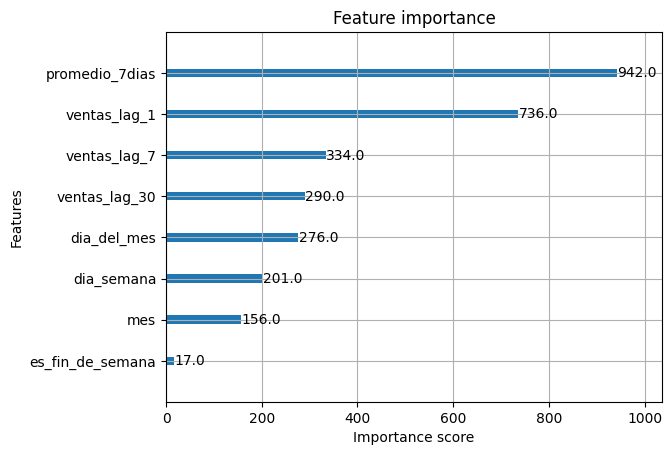

In [ ]:
# 4. Predicciones
test['prediccion'] = model_xgb.predict(X_test)

# 5. Métricas
mae = mean_absolute_error(test[target], test['prediccion'])
rmse = np.sqrt(mean_squared_error(test[target], test['prediccion']))

print(f"Error Medio Absoluto (MAE): {mae:.2f} unidades")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f}")

# 6. Ver importancia de las variables
# Esto te dirá si lo más importante para vender es el día de la semana o lo que se vendió ayer
xgb.plot_importance(model_xgb, importance_type='weight')